<a href="https://colab.research.google.com/github/KyeongHoSeong/rlstudio/blob/main/GradientTape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

reference: https://rfriend.tistory.com/556

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. 즉시 실행 모드에서 자동미분을 하기 위해 Gradient tapes 이 필요한 이유


## lab 
y = a * x 
 - 상수: a, x
 - 변수: x

문제(목표): 
  1. 이 방정식을 오차 역전파로 풀어서 
  2. 변수 x를 구하고자 한다.

RL에서 
  1. 신경망을 학습 시켜서
  2. 상태 s에서 최적 행동 a를 출력하고자 한다.

해결 방안: 'loss = sqrt(a*x -y) / 2'를 최소로 하는 x를 구한다.


아래 예의 경우 8.0 = 2.0 * x 방정식 함수로 부터 변수 x 의 값을 구하고자 합니다. x 를 10.0 에서 시작해서 abs(a * x - y) 손실함수 값을 최소로 하는 x 를 구하려면 '손실함수에 대한 x의 미분 (the gradient of the loss with respect to x)를 구해서 x 값을 미분값만큼 빼서 갱신해주어야 합니다. 

In [ ]:
a, y = tf.constant(2.0), tf.constant(8.0)
x = tf.Variable(10.0) # In practice, we start with a random value
loss = tf.math.abs(a * x - y)
loss

<tf.Tensor: shape=(), dtype=float32, numpy=12.0>

## 문제 
TensorFlow 2.x 버전에서의 Python 즉시실행모드(eager mode)에서 손실(Loss) 을 "바로 즉시 계산"(eager execution)해 버린다.

그래서 출력 결과를 보면 numpy=12.0 인 Tensor 상수가 되어 버려서 자동미분을 하려고 하면 문제가 생긴다.

왜냐하면 자동미분을 하기 위해 필요한 함수와 계산 식의 연산 과정과 입력 값에 대한 정보가 즉시실행모드에서는 없기 때문입니다. (입력 값과 연산 과정은 저장 안하고 즉시실행해서 결과만 출력했음).  


# 2. TensorFlow에서 Gradient tapes를 이용해 자동미분하는 방법
이 문제를 해결하기 위해 TensorFlow는 중간 연산 과정(함수, 연산)을 테이프(tape)에 차곡차곡 기록해주는 Gradient tapes 를 제공합니다. 


## with tf.GradientTape() as tape: 
1. tf.GradientTape를 사용하여 저장할 tape을 지정해주면, 
2. 이후의 GradientTape() 문맥 아래에서의 TensorFlow의 연관 연산 코드는 tape에 저장
3. 이렇게 tape에 저장된 연산 과정 (함수, 연산식) 을 가져다가 TensorFlow는 
  - dx = tape.gradient(loss, x)로 후진 모드 자동 미분 (Reverse mode automatic differentiation) 방법으로 손실에 대한 x의 미분을 계산
  
4. 이렇게 계산한 손실에 대한 x의 미분을 역전파(backpropagation)하여 x의 값을 갱신(update)하는 작업을 반복하므로써 변수 x의 답을 찾아가는 학습을 진행.


위의 (1)번에서 소개한 8.0 = 2.0 * x 의 방정식에서는 변수 x = 4.0 이 답이다.

TensorFlow 의 GradientTape() 과 tape.gradient() 를 사용해서 오차 역전파 방법으로 갱신하여 문제를 풀어보자. 

처음에 x = 10.0에서 시작해서 4회 반복하니 x = 4.0 으로 답을 잘 찾아간다.


In [ ]:
# UDF for training
def train_func():
    with tf.GradientTape() as tape:
        loss = tf.math.abs(a * x - y)

    # calculate gradient
    dx =  tape.gradient(loss, x)
    print('x = {}, dx = {:.2f}'.format(x.numpy(), dx))

    # update x <- x - dx
    x.assign(x - dx)


In [ ]:
# Run train_func() UDF repeately
for i in range(4):
    train_func()

x = 10.0, dx = 2.00
x = 8.0, dx = 2.00
x = 6.0, dx = 2.00
x = 4.0, dx = 0.00


함수 y = x^2에서 (Target) y에 대한 (Source) x의 미분 (derivative of target y with respect to source x) 을 TensorFlow의 GradientTape.gradient() 메소드를 사용해서 계산해보겠습니다. 

x = 4.0  이므로,  dy/dx 를 풀면 2 * 4.0 = 8.0 

GradientTape.gradient(target, sources)

In [ ]:
x = tf.Variable(4.0)
with tf.GradientTape() as tape:
  y = x ** 2

# dy = 2x * dx
dy_dx = tape.gradient(y, x)
dy_dx.numpy()


8.0

위의 간단한 예에서는 스칼라(Scalar) 를 사용하였다면, tf.GradientTape() 은 어떤 형태의 텐서에 대해서도 사용할 수 있습니다. GradientTape.gradient(target, sources) 에서 sources 에는 여러개 변수를 리스트나 사전형(Dictionary) 형태로 입력해줄 수 있습니다.  


In [ ]:
# tf.GradientTape works as easily on any tensor. 
w = tf.Variable(tf.random.normal((4, 2)), name='w')
print('w.shape: ', w.shape)
print(w)
b = tf.Variable(tf.zeros(2, dtype=tf.float32), name='b')
x = [[1.0, 2.0, 3.0, 4.0]]

with tf.GradientTape(persistent=True) as tape:
  y = x @ w + b
  loss = tf.reduce_mean(y ** 2)

# To get the gradienet of y w.r.t both variables, w and b
[dl_dw, dl_db] = tape.gradient(loss, [w, b])

print("loss", loss)
print('w: ', w)
print('b: ', b)

w.shape:  (4, 2)
<tf.Variable 'w:0' shape=(4, 2) dtype=float32, numpy=
array([[-1.2830628 , -0.44803572],
       [ 0.44576037, -1.0096728 ],
       [-1.382512  ,  1.4505912 ],
       [ 0.24179527, -0.54283214]], dtype=float32)>
loss tf.Tensor(6.4203887, shape=(), dtype=float32)
w:  <tf.Variable 'w:0' shape=(4, 2) dtype=float32, numpy=
array([[-1.2830628 , -0.44803572],
       [ 0.44576037, -1.0096728 ],
       [-1.382512  ,  1.4505912 ],
       [ 0.24179527, -0.54283214]], dtype=float32)>
b:  <tf.Variable 'b:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>


Target에 대한 Source의 미분 결과는 Source의 형상(shape)을 따릅니다. 가령, 위의 예에서 손실함수(Loss)에 대한 가중치(w)의 미분 (derivative of loss with respect to weight) 의 결과는 Source에 해당하는 가중치(w)의 형상을 따라서 (4, 2) 가 됩니다. 


In [ ]:
print('shape of w:', w.shape)
print('shape of dl_dw:', dl_dw.shape)

shape of w: (4, 2)
shape of dl_dw: (4, 2)


## 3. 시그모이드 함수의 자동미분 시각화 (Auto-diff plot of Sigmoid function)
딥러닝에서 활성화 함수 중의 하나로 사용되는 S 곡선 모양의 시그모이드 함수 (Sigmoid function) 은 아래와 같습니다. 

<img src="https://t1.daumcdn.net/cfile/tistory/999B4A4F5F6C37A334" />

이 시그모이드 함수를 x 에 대해서 미분하면 아래와 같습니다. 

<img src="https://t1.daumcdn.net/cfile/tistory/99C84C365F6C398E36" />

시그모이드 함수와 시그모이드 함수의 미분 값을 
- x 가 -10.0에서 10.0 사이의 200개의 관측치에 대해 
- TensorFlow의 tf.GradientTape()와 GradientTae=pe.gradient(Sigmoid_func, x) 로 계산해서 
- 하나의 그래프에 겹쳐서 시각화를 해보겠습니다. 

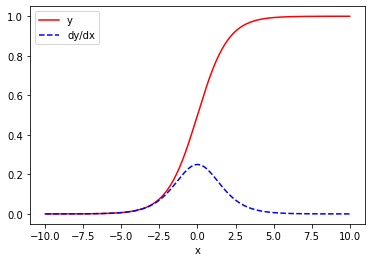

In [ ]:
x = tf.linspace(-10.0, 10.0, 200+1)

with tf.GradientTape() as tape:
    tape.watch(x)
    y = tf.nn.sigmoid(x)

# For an element-wise calculation, 
# the gradient of the sum gives the derivative of each element
# with respect to its input-element, since each element is independent.
dy_dx = tape.gradient(y, x)

# plot of y, dy/dx
plt.plot(x, y, 'r-', label='y')
plt.plot(x, dy_dx, 'b--', label='dy/dx')
plt.legend()
_ = plt.xlabel('x')
plt.show()


## 4. 테이프가 "볼(저장)" 것을 조정하는 방법 (Colltrolling whtat the tape "watches")

TensorFlow 가 오차역전파 알고리즘으로 학습(training by backpropagation algorithm)할 때 사용하는 자동미분은 
'학습 가능한 변수 (trainable tf.Variable)'를 대상으로 한다.

따라서 만약에 
1. 변수가 아닌 상수 ('tf.Tensor') 라면 TensorFlow가 안 보는 (not watched), 즉 기록하지 않는 (not recorded) 것이 기본 설정이므로 자동 미분을 할 수 없으며, 
2. 변수(tf.Variable)라고 하더라도 '학습 가능하지 않으면 (not trainable)' 자동 미분을 할 수 없다. 

In [ ]:

# A trainable variable
x0 = tf.Variable(3.0, name='x0')

# Not trainable
x1 = tf.Variable(3.0, name='x1', trainable=False)

# Not a Variable: A variable + tensor returns a tensor.
x2 = tf.Variable(2.0, name='x2') + 1.0

# Not a variable
x3 = tf.constant(3.0, name='x3')

with tf.GradientTape() as tape:
    y = (x0**2) + (x1**2) + (x2**2)

# Only x0 is a trainable tf.Variable, --> can calculate gradient
grad = tape.gradient(y, [x0, x1, x2, x3]) 

for g in grad:
    print(g)

tf.Tensor(6.0, shape=(), dtype=float32)
None
None
None


None # <-- dy_dx1, not trainable 

None # <-- dy_dx2, not a variable 

None # <-- dy_dx3, not a variable

y 에 대한 tf.Tensor 인 x의 미분을 구하기 위해서는 
GradientTape.watch(x) 를 호출해서 tf.Tensor 인 x를 테이프에 기록해주면 된다.
 


In [ ]:
x = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(x) # watch 'x' and then record it onto tape
    y = x**2

# dy = 2x * dx
dy_dx = tape.gradient(y, x)
print(dy_dx.numpy())


6.0


TensorFlow의 테이프에 기록되는 '학습 가능한 변수'는 GradientTape.watched_variables() 메소드로 확인할 수 있습니다. 

In [ ]:
[var.name for var in tape.watched_variables()]

[]

반대로, 모든 변수(tf.Variable)를 테이프에 기록하는 TensorFlow의 기본설정을 비활성화(disable)하려면 watch_accessed_variables=False 으로 매개변수를 설정해주면 됩니다. 

아래의 예에서는 x0, x1 의 두 개의 tf.Variable 모두를 watch_accessed_variables=False 로 비활성화해놓고, GradientTape.watch(x1) 으로 x1 변수만 테이프에 기록해서 자동 미분을 해보겠습니다.


In [ ]:
x0 = tf.Variable(0.0)
x1 = tf.Variable(10.0)

with tf.GradientTape(watch_accessed_variables=False) as tape:
    tape.watch(x1)
    y0 = tf.math.sin(x0)
    y1 = tf.nn.softplus(x1)
    y = y0 + y1
    ys = tf.reduce_sum(y)

# dy = 2x * dx
grad = tape.gradient(ys, {'x0': x0, 'x1': x1})

print('dy/dx0:', grad['x0'])
print('dy/dx1:', grad['x1'].numpy())



dy/dx0: None
dy/dx1: 0.9999546


## 5. Python 조건절을 사용한 테이프 기록 흐름을 조정
     (Control flow using Python condition statements)

Python 의 조건절을 이용한 분기문을 이용하면 TensorFlow 의 tf.GradientTape() 맥락 아래에서 테이프에 기록하는 연산 과정의 흐름을 조건절에 해당하는 것만 취사선택해서 기록할 수 있습니다. 



아래 예에서는 if x > 0.0 일 때는 result = v0, 그렇지 않을 때는(else) result = v1 ** 2 로 result 의 연산을 다르게 해서 테이프에 기록하고, GradientTape.gradient() 로 자동미분 할 때는 앞서 if else 조건절에서 True에 해당되어서 실제 연산이 일어났던 연산에 미분을 연결해서 계산하라는 코드입니다. 



아래 예에서는 x = tf.constant(1.0) 으로서 if x > 0.0 조건절을 만족(True)하므로 result = v0 연산이 실행되고 뒤에 tape.gradient()에서 자동미분이 되었으며, else 조건절 아래의 연산은 실행되지 않았으므로 뒤에 tape.gradient()의 자동미분은 해당되지 않았습니다 (dv1: None).  

In [ ]:
x = tf.constant(1.0)
v0 = tf.Variable(2.0)
v1 = tf.Variable(2.0)

with tf.GradientTape(persistent=True) as tape:
    tape.watch(x)
    # Python flow control
    if x > 0.0:
        result = v0
    else:
        result = v1**2 

dv0, dv1 = tape.gradient(result, [v0, v1])

print('dv0:', dv0)
print('dv1:', dv1)


dv0: tf.Tensor(1.0, shape=(), dtype=float32)
dv1: None


In [ ]:
    #@tf.function
    def train(self, states, actions, rewards, next_states, dones):
        
        # 1. 모델 파리미터를 가져온다.
        critic_variable = self.critic_model.trainable_variables
        
        # 2. 그레디언트 테이프가 미분할 값들을 주목
        with tf.GradientTape() as tape_critic:
            # 특정 파라미터를 watch에 넣어주면 이 파라미터를 중심으로 graph(식)을 만든다.  
            tape_critic.watch(critic_variable)
             
            # 3. loss를 구한다.
            critic_loss = self.critic_loss(states, rewards, dones)

        # 4. 미분한다.
        critic_grads = tape_critic.gradient(critic_loss, critic_variable)
        # 5. 미분 값을 최소화 하는 방향으로 weight를 조정한다.
        self.critic_opt.apply_gradients(zip(critic_grads, critic_variable))

        advantages = self.compute_advantages(states, rewards, dones)
        actor_variable = self.actor_model.trainable_variables
        with tf.GradientTape() as tape:
            tape.watch(actor_variable)
            actor_loss = self.actor_loss(states, actions, advantages)

        actor_grads = tape.gradient(actor_loss, actor_variable)
        self.actor_opt.apply_gradients(zip(actor_grads, actor_variable))